In [11]:
# Automatically reload the package if you edit the .py files
%load_ext autoreload
%autoreload 2

import warnings; warnings.filterwarnings("ignore") # remove scanpy warnings for the tutorial.
# Import the new package name
import decipher_vz as dc_vz

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
import logging
import pandas as pd
import scanpy as sc
import os
from sklearn.cluster import KMeans

from matplotlib import pyplot as plt
import seaborn as sns

import matplotlib as mpl

import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from scipy.sparse.csgraph import minimum_spanning_tree
from sklearn.metrics import silhouette_samples

In [13]:
dc_vz.pl.activate_journal_quality()

# Load data

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scanpy as sc 

In [15]:
import matplotlib
print(matplotlib.__version__)
import IPython
print(IPython.__version__)

3.11.0
9.15.0


In [16]:
def run_pipeline(filepath, shift):
    folder = f"/Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods/Data/Simulated Data/Simulated Adata/{shift}"
    adata = sc.read_h5ad(f"{folder}/{filepath}")
    adata.uns["color_palette"] = None
    color_palette = None

    decipher_config = DecipherConfig(learning_rate=1e-3, seed=1)

    # Train Decipher
    d1, val1 = dc_vz.tl.decipher_train(
        adata, decipher_config, plot_kwargs= {"color": "shift"}, 
        batch_key="shift",
        plot_every_k_epochs=5,
    )
    return adata, d1, val1

In [17]:
def visualize_shift_latentt(adata):
    decipher_z = adata.obsm["decipher_z"]
    shift_labels = adata.obs["shift"]

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))
    sc.pl.embedding(adata, basis="decipher_v", color="shift",
                    show=False, ax=axes[0], size=50)
    sc.pl.embedding(adata, basis="decipher_v", color="latent_t",
                    show=False, ax=axes[1], size=30)
    plt.tight_layout()
    plt.show()

## Note:
Change folder location here

Epoch 89 (batch 22/22) | | train elbo: 37.18 (last epoch: 36.38) | val ll: 46.86:   9%|▉         | 89/1000 [00:21<03:44,  4.06it/s]2026-07-10 16:07:13,531 | INFO : Early stopping has been triggered.
2026-07-10 16:07:13,533 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-07-10 16:07:13,533 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-07-10 16:07:13,535 | INFO : Saving decipher model with run_id 2026-07-10-16-07-13-chocolaty-azure-clique.


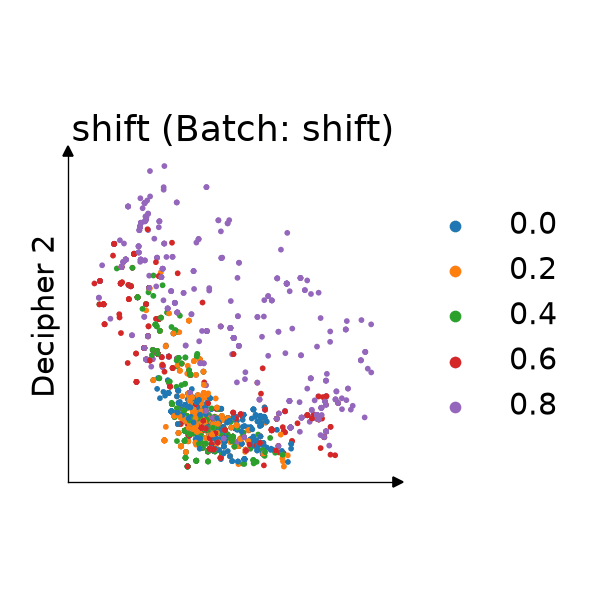

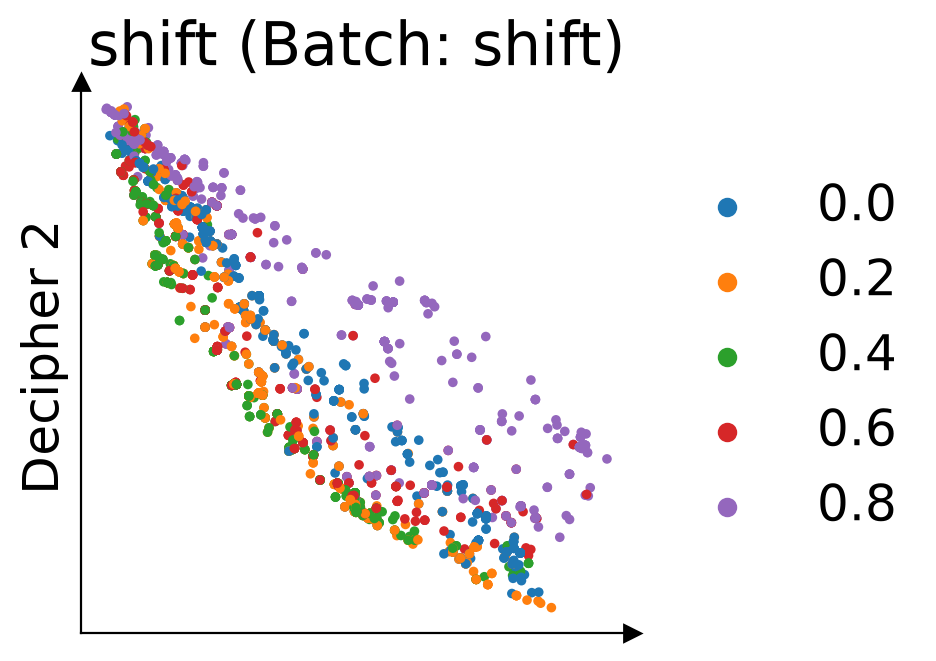

In [18]:
from decipher_vz.tools._decipher import DecipherConfig

adata1, d1, val1 = run_pipeline("0710_vz_0.20_0.40_0.60_0.80.h5ad", shift="v-to-z")

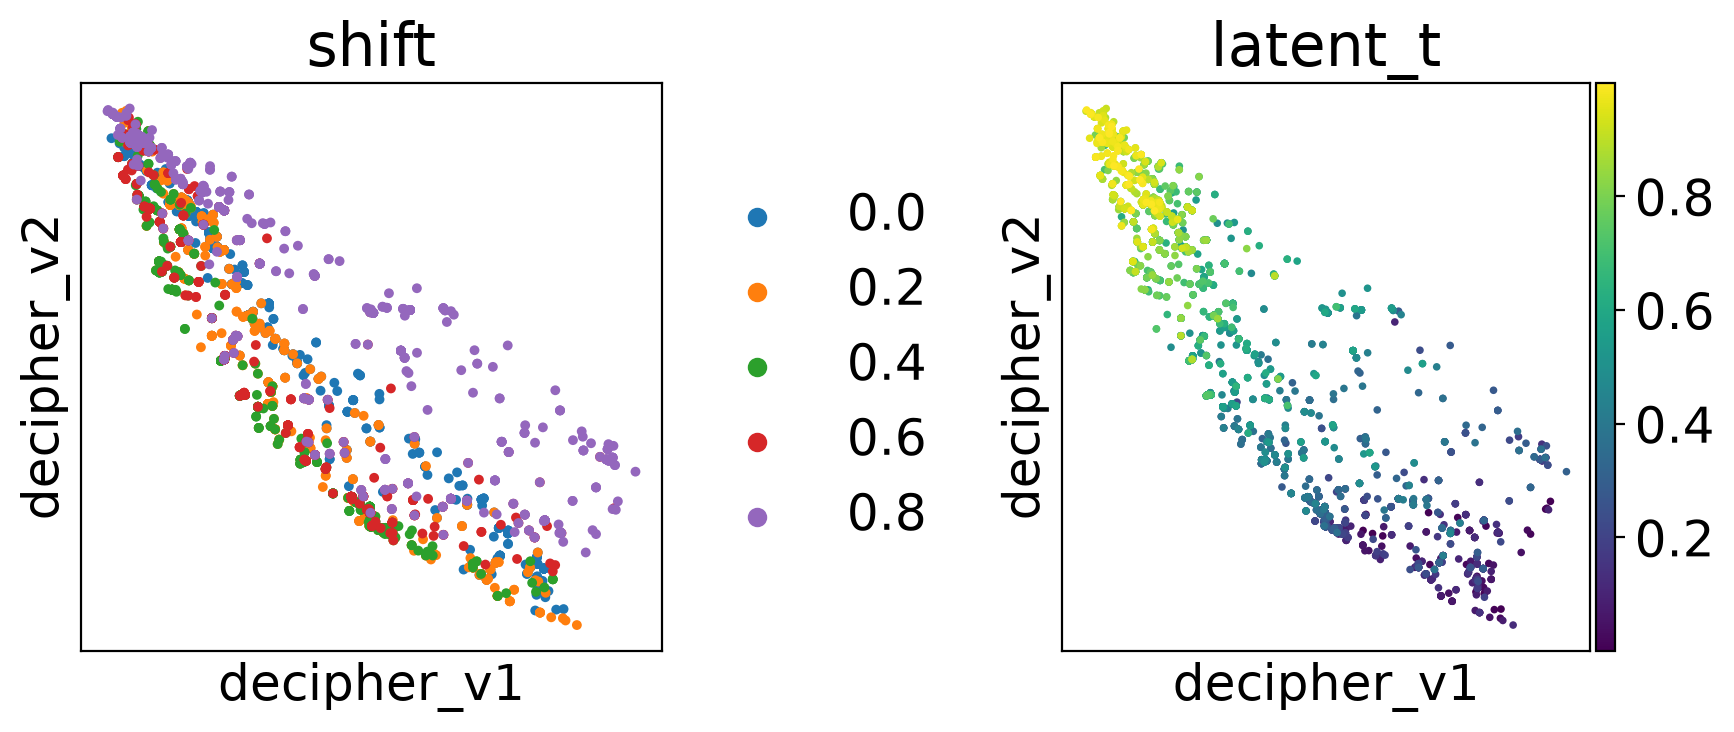

In [19]:
visualize_shift_latentt(adata1)

In [20]:
# Perform Leiden clustering
dc_vz.tl.cell_clusters(adata1, leiden_resolution = 0.05, n_neighbors = 25, seed=341)
adata1.obs['decipher_clusters'].nunique()

2026-07-10 16:07:14,065 | INFO : Clustering cells using scanpy Leiden algorithm.
2026-07-10 16:07:14,065 | INFO : Step 1: Computing neighbors with `sc.pp.neighbors`, with the representation decipher_z.
2026-07-10 16:07:18,192 | INFO : Step 2: Computing clusters with `sc.tl.leiden`, and resolution 0.05.
2026-07-10 16:07:18,362 | INFO : Added `.obs['decipher_clusters']`: the cluster labels.


41

In [21]:
# Print number of cells per cluster
adata1.obs['decipher_clusters'].value_counts().sort_index()

#Which cluster does a cell belong to
adata1.obs["decipher_clusters"]

#Ground truth for each cell, or differentiation progress
adata1.obs["latent_t"]

#Group by clusters, and then take average of latent_t
adata1.obs.groupby("decipher_clusters")["latent_t"].mean()

#Group by clusters, take average of latent_t, and then list in ascending order
adata1.obs.groupby("decipher_clusters")["latent_t"].mean().sort_values()

#Group by clusters, take average of latent_t, list in asc. order, and then turn into list
ground_truths = adata1.obs.groupby("decipher_clusters")["latent_t"].mean().sort_values().index.tolist()


In [22]:
# Keep clusters with enough cells
filtered_clusters = adata1.obs["decipher_clusters"].value_counts() > 10

# Apply mask
filtered_cluster_ids = set(filtered_clusters[filtered_clusters].index)

ground_truths = adata1.obs.groupby("decipher_clusters")["latent_t"].mean().sort_values().index.tolist()
ground_truths = [c for c in ground_truths if c in filtered_cluster_ids]

In [23]:
# Computes points that accumulate to form a piecewise linear path through decipher-v space
dc_vz.tl.trajectories(adata1, dc_vz.tl.TConfig("trajectory", cluster_ids_list = ground_truths))

2026-07-10 16:07:18,427 | INFO : Trajectory trajectory : ['3', '29', '31', '24', '14', '33', '19', '18', '21', '0', '26', '7', '25', '9', '28', '1', '12', '17', '30', '6', '11', '4', '34', '22', '32', '16', '8', '5', '23', '27', '13', '20', '15', '2', '10'])
2026-07-10 16:07:18,433 | INFO : Added trajectory trajectory to `adata.uns['decipher']['trajectories']`.


2026-07-10 16:07:18,457 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-07-10 16:07:18,458 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.


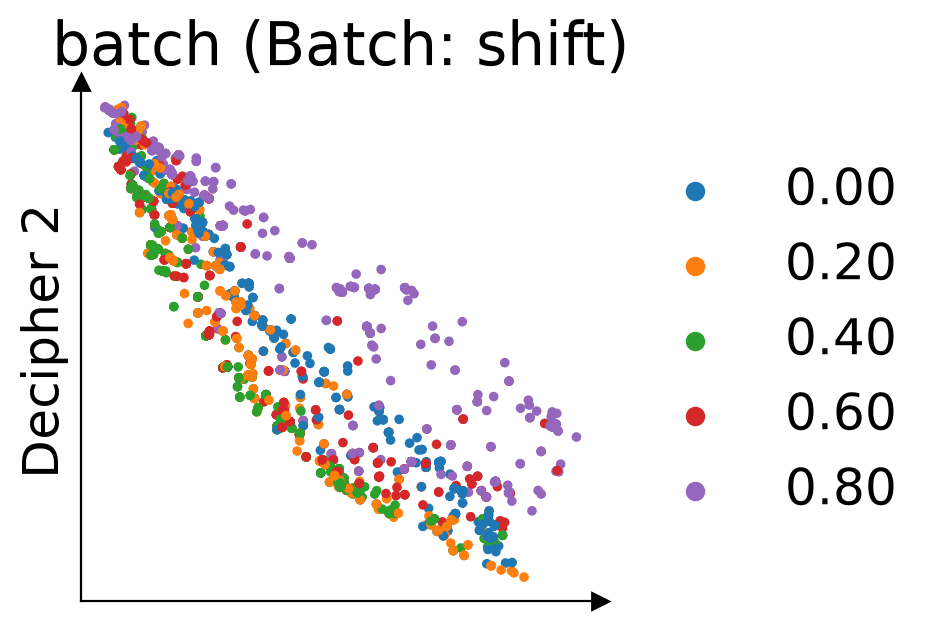

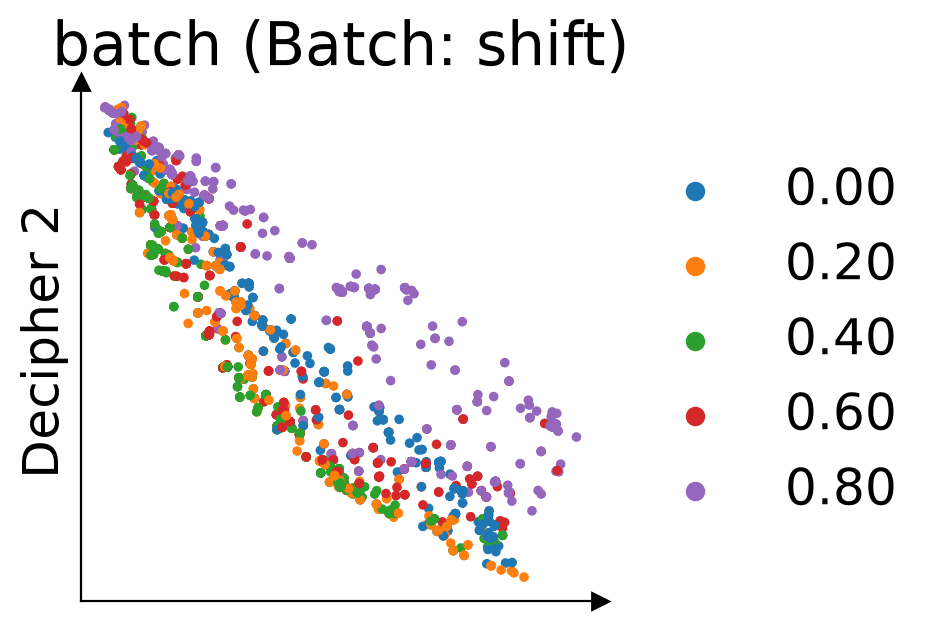

In [24]:
dc_vz.tl.decipher_rotate_space(adata1)
dc_vz.pl.decipher(adata1, color="batch")

In [25]:
dc_vz.tl.decipher_time(adata1)

2026-07-10 16:07:18,578 | INFO : Added `.obs['decipher_time']`: the decipher time of each cell.


In [26]:
# Check that decipher_time was actually populated (not all NaN)
print(adata1.obs["decipher_time"].isna().sum(), "NaN cells")
print(adata1.obs["decipher_time"].describe())

48 NaN cells
count    2452.000000
mean        9.412224
std         6.042161
min         0.090161
25%         3.384050
50%        10.328466
75%        14.779424
max        18.763547
Name: decipher_time, dtype: float64


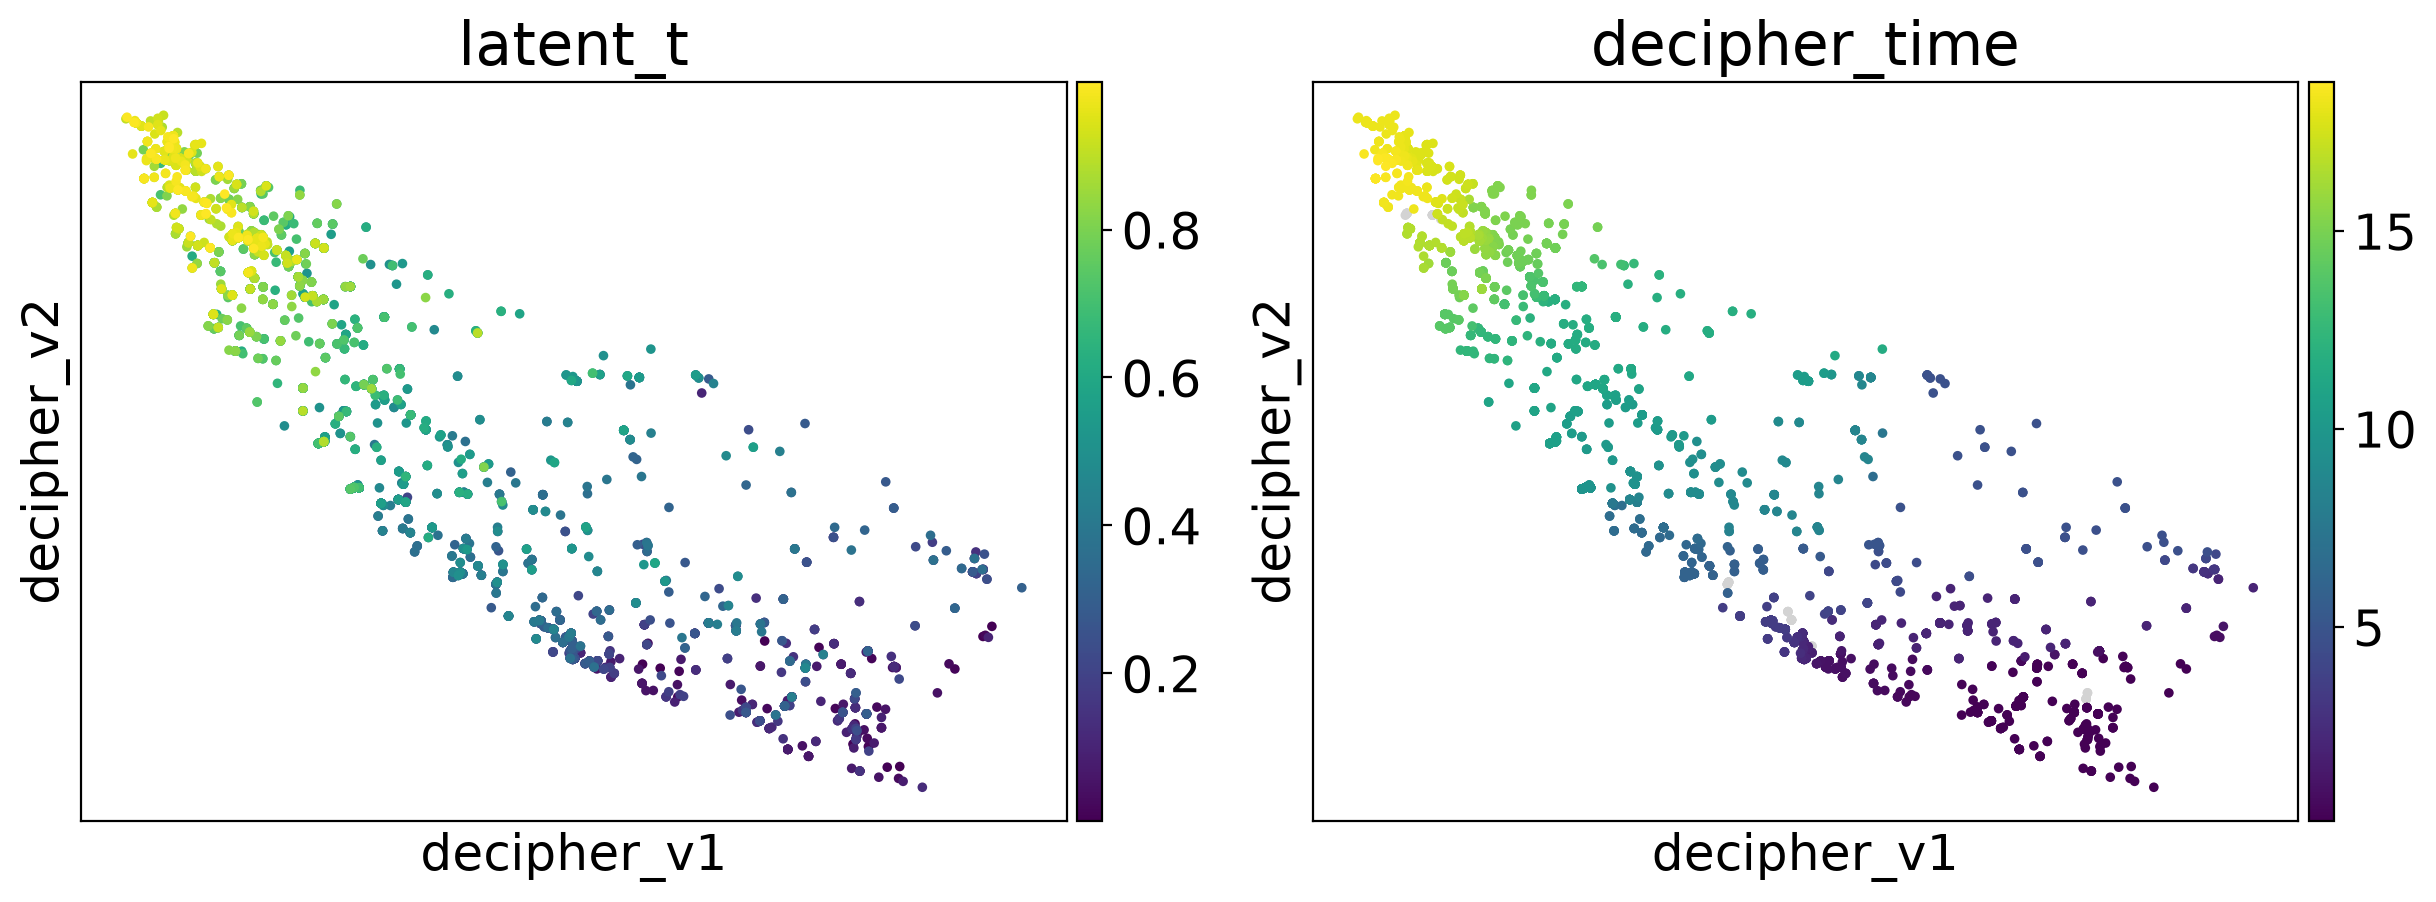

In [27]:
sc.pl.embedding(adata1, basis = "decipher_v", color = ["latent_t", "decipher_time"])

In [28]:
from scipy.stats import spearmanr

for b in sorted(adata1.obs["batch"].unique()):
    mask = adata1.obs["batch"] == b
    # drop NaN cells (those not on trajectory)
    valid = mask & adata1.obs["decipher_time"].notna()
    rho, pval = spearmanr(adata1.obs.loc[valid, "decipher_time"], adata1.obs.loc[valid, "latent_t"])
    print(f"batch={b}  rho={rho:+.4f}  p={pval:.2e}")

batch=0.00  rho=+0.9367  p=1.24e-223
batch=0.20  rho=+0.9375  p=1.02e-226
batch=0.40  rho=+0.9456  p=4.44e-240
batch=0.60  rho=+0.9456  p=8.80e-238
batch=0.80  rho=+0.9382  p=2.76e-230
